In [3]:
import pandas as pd

df = pd.read_csv('/workspaces/netflix_data_analytics/data/netflix-rotten-tomatoes-metacritic-imdb.csv')

# Quick check
df = df.replace('', None)
df = df.fillna(None)
# df.head(1)




In [4]:

#converting columns to numeric
num_columns=['IMDb Score', 'Rotten Tomatoes Score', 'Metacritic Score', 'IMDb Votes', 'Boxoffice', 'Hidden Gem Score']
for col in num_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

#converting date columns
df.columns
df['Release Date'] = pd.to_datetime(df['Release Date'],errors='coerce')
df['Netflix Release Date'] = pd.to_datetime(df['Netflix Release Date'],errors='coerce')
df['Boxoffice'] = df['Boxoffice'].astype(str).str.replace(r'[^\d.-]', '', regex=True).astype(float)


DATA ENGINEERING

In [9]:
# Time between release and Netflix addition
df['gap_between_netflix_release_and_release'] = (df['Netflix Release Date'] - df['Release Date']).dt.days
df.columns
# df[['Netflix Release Date','Release Date','gap_between_netflix_release_and_release']]

#Number of countries available
# display(df)
# df[['Title','Country Availability']]
df["Country Count"]=df['Country Availability'].str.split(',').str.len().fillna(0).astype(int)
df["Language Count"]=df['Languages'].str.split(',').str.len().fillna(0).astype(int)
# df[['Title','Languages','Language Count','IMDb Votes']]
# df.columns
df['is_hidden_gem'] = df.apply(lambda row: row['Hidden Gem Score'] >= 7 and row['IMDb Votes'] < 50, axis=1)
df[['Title','Hidden Gem Score','IMDb Votes','is_hidden_gem']]

,Title,Hidden Gem Score,IMDb Votes,is_hidden_gem
0,Lets Fight Ghost,4.3,205926.0,False
1,HOW TO BUILD A GIRL,7.0,2838.0,False
2,Centigrade,6.4,1720.0,False
3,ANNE+,7.7,1147.0,False
4,Moxie,8.1,63.0,False
...,...,...,...,...
15475,K-POP Extreme Survival,NaN,NaN,False
15476,DreamWorks Shreks Swamp Stories,NaN,NaN,False
15477,DreamWorks Happy Holidays from Madagascar,8.4,71.0,False
15478,DreamWorks Holiday Classics,8.2,82.0,False


In [10]:
df['Genre'] = df['Genre'].str.split(',')
df_exploded = df.explode('Genre')

MOVIES VS SERIES

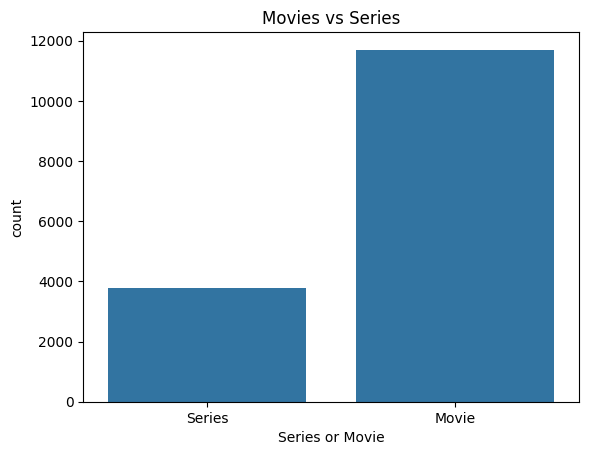

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Series or Movie', data=df)
plt.title('Movies vs Series')
plt.show()

TOP GENRES

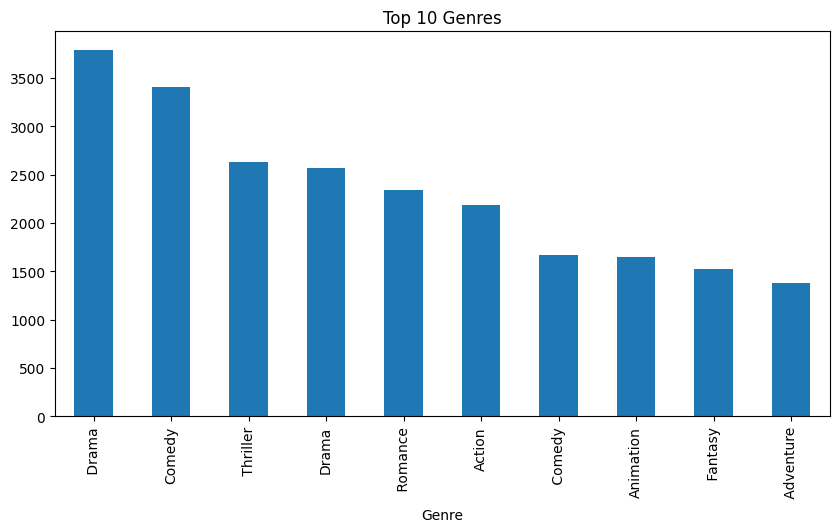

In [22]:

top_genres = df_exploded['Genre'].value_counts().head(10)
top_genres  
top_genres.plot(kind='bar', figsize=(10,5), title='Top 10 Genres')
plt.show()

Titles added per year

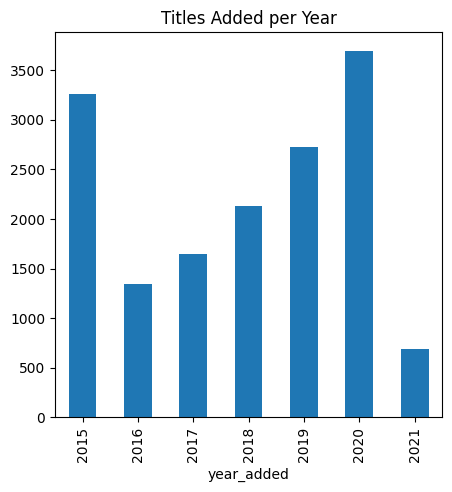

In [25]:
df['year_added'] = df['Netflix Release Date'].dt.year
df.groupby('year_added').size().plot(kind='bar', figsize=(5,5), title='Titles Added per Year')
plt.show()

In [26]:
df.to_csv('/workspaces/netflix_data_analytics/data/netflix_cleaned.csv', index=False)